Shapes: (37500, 32) (12500, 32)


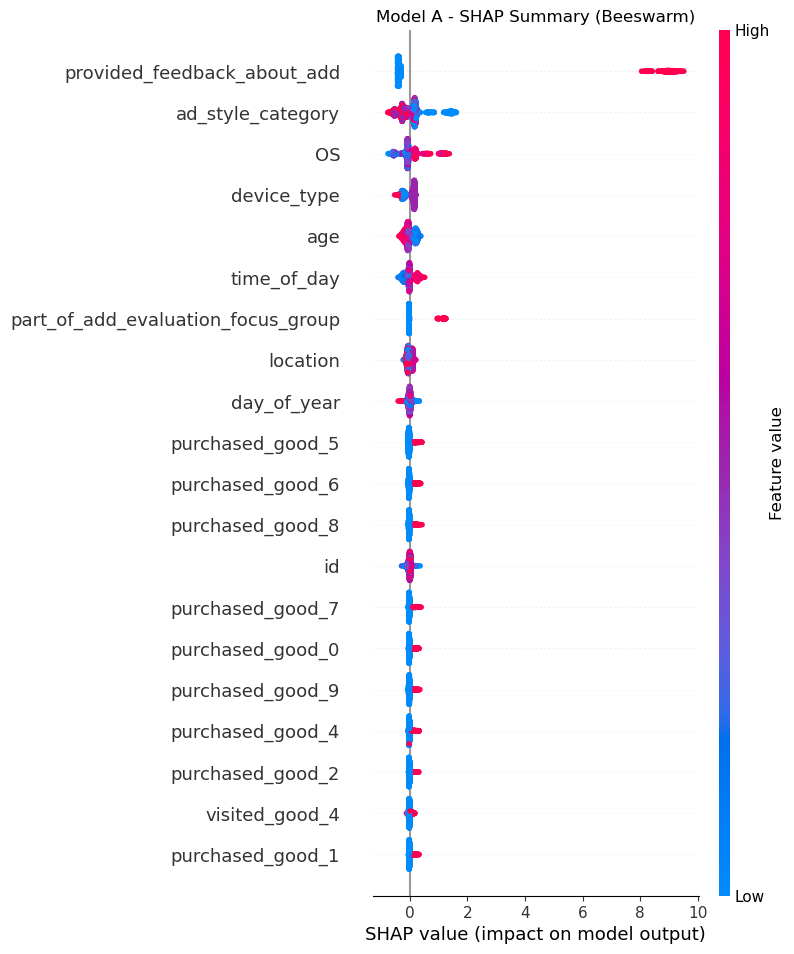

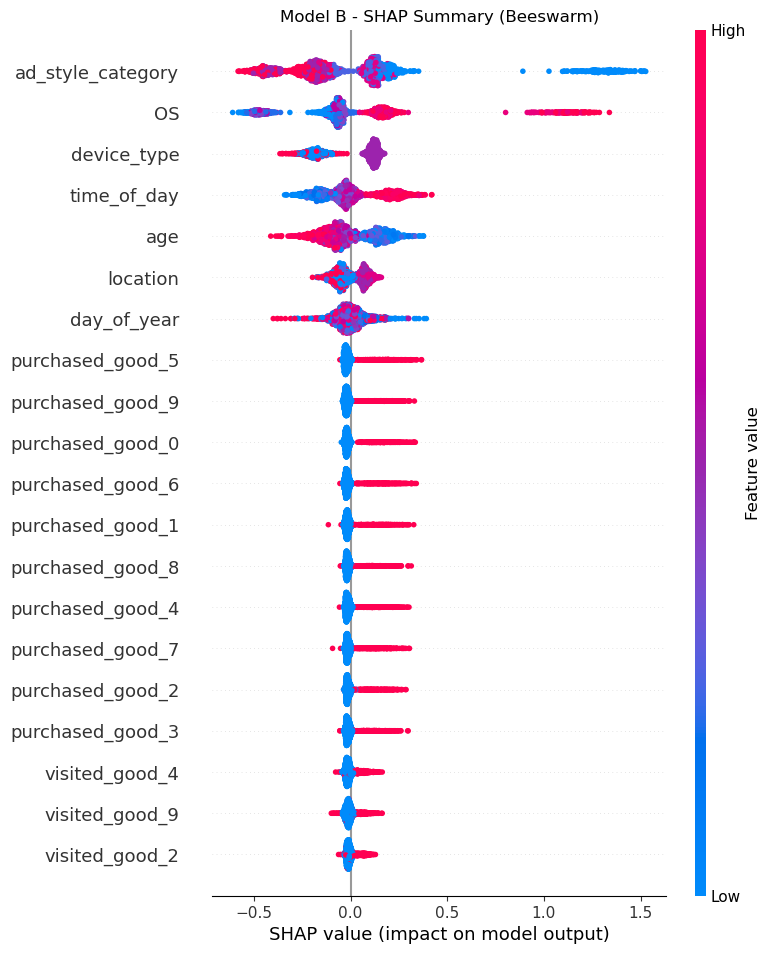

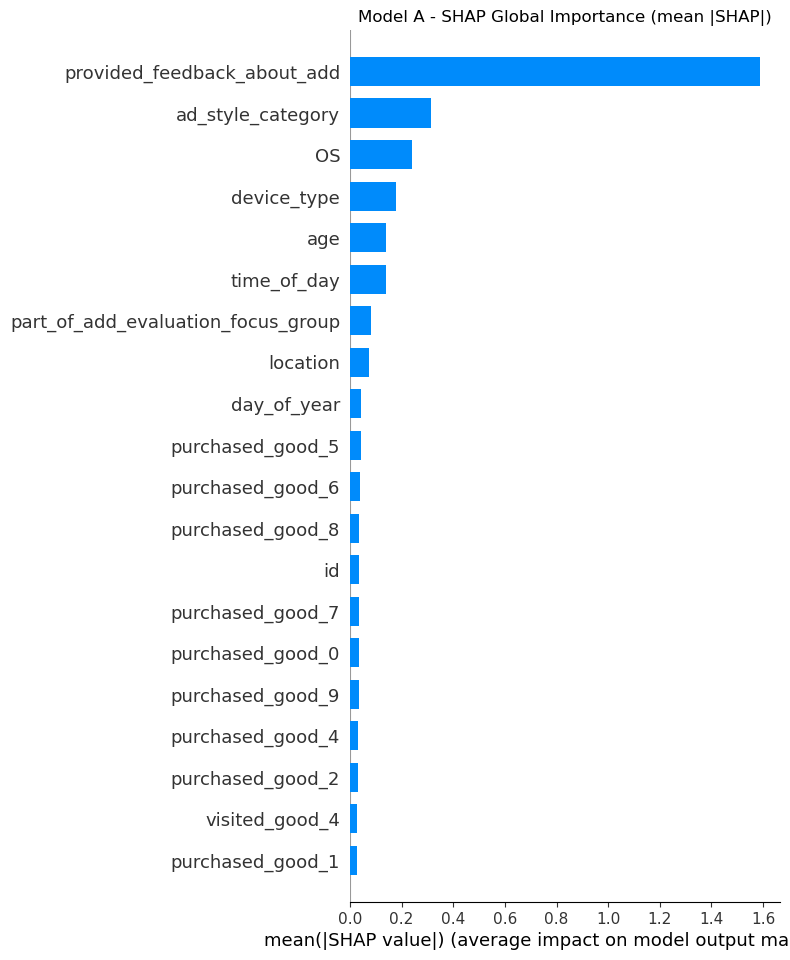

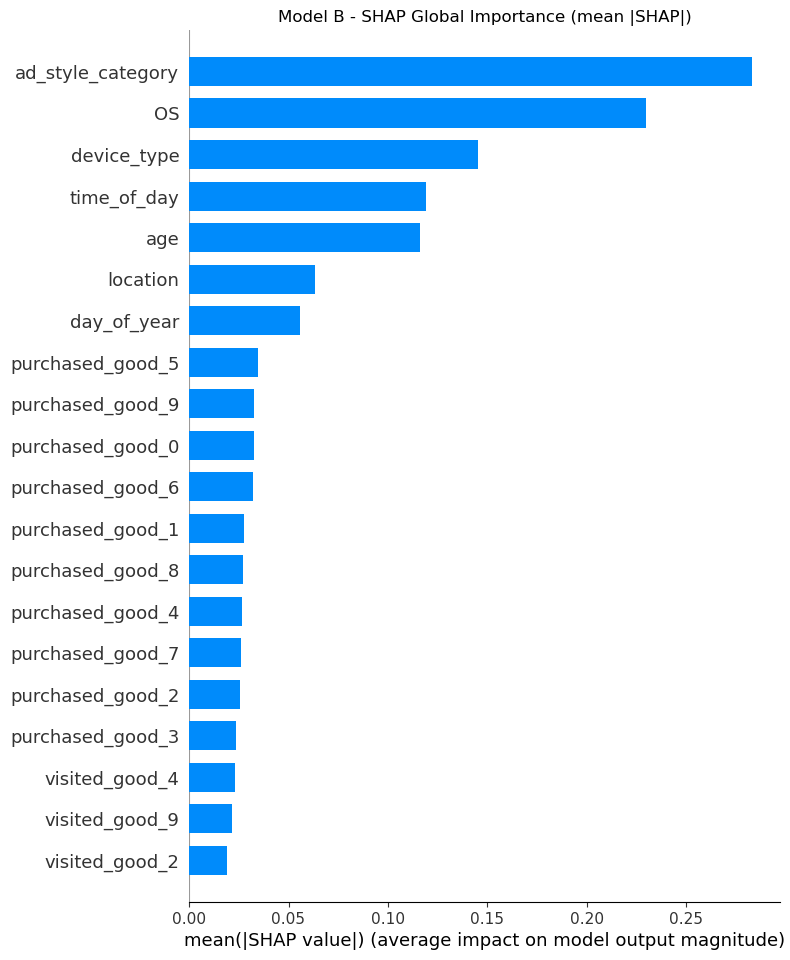

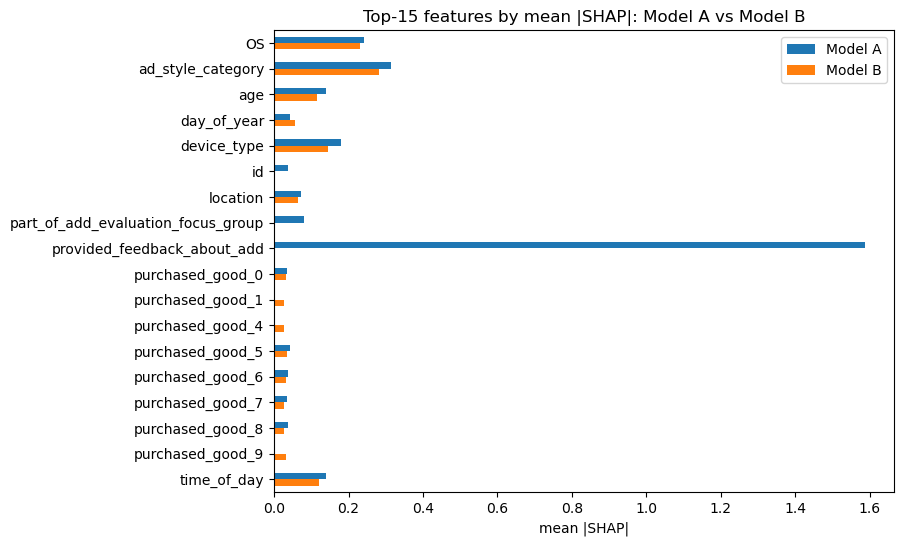

Local waterfalls - Model A


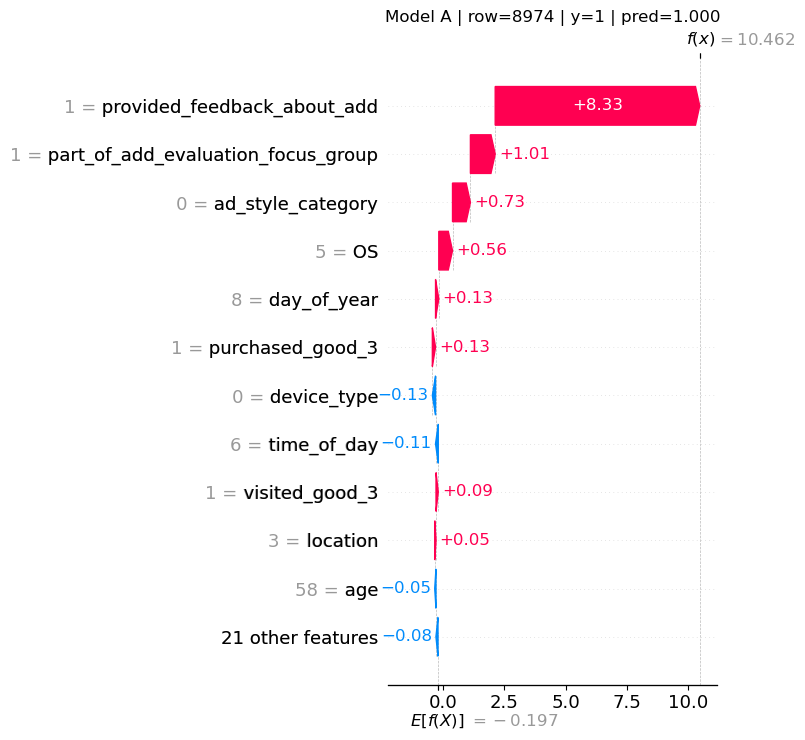

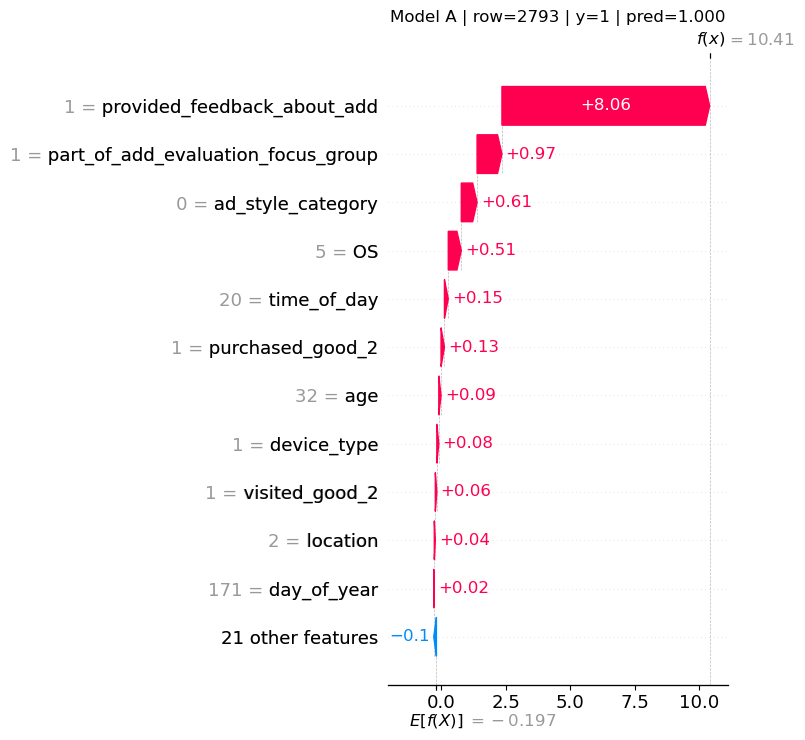

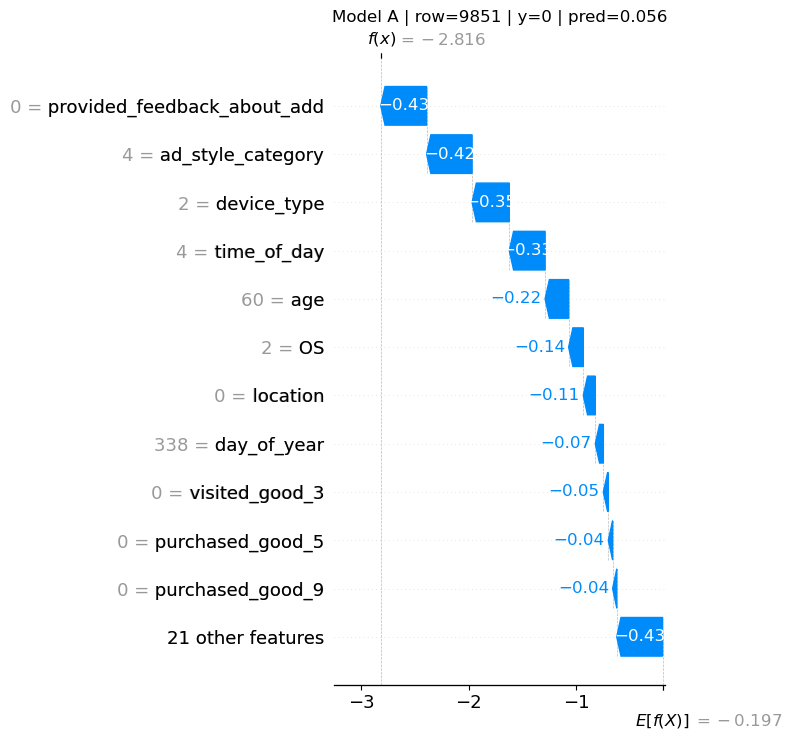

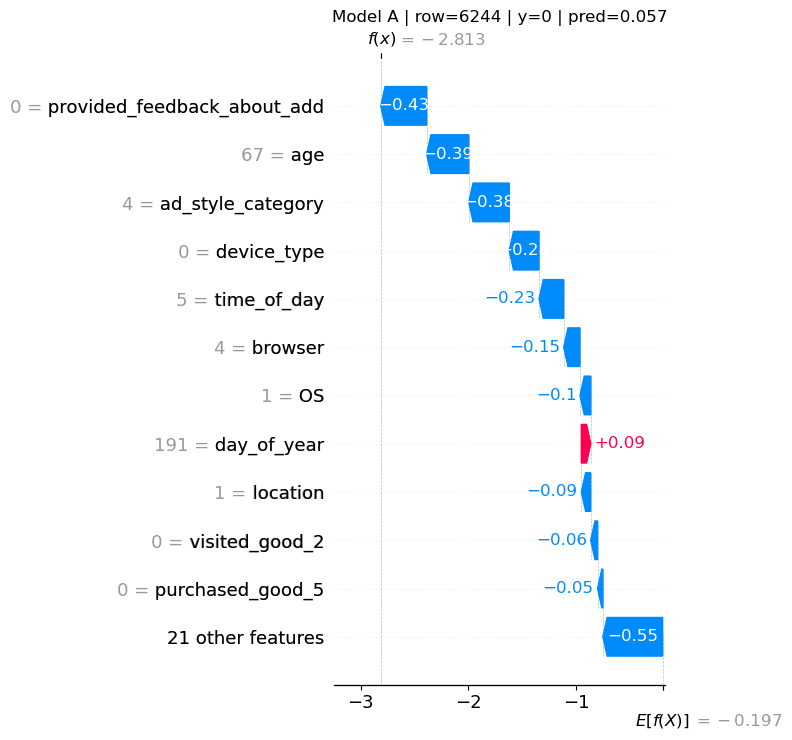

Local waterfalls - Model B


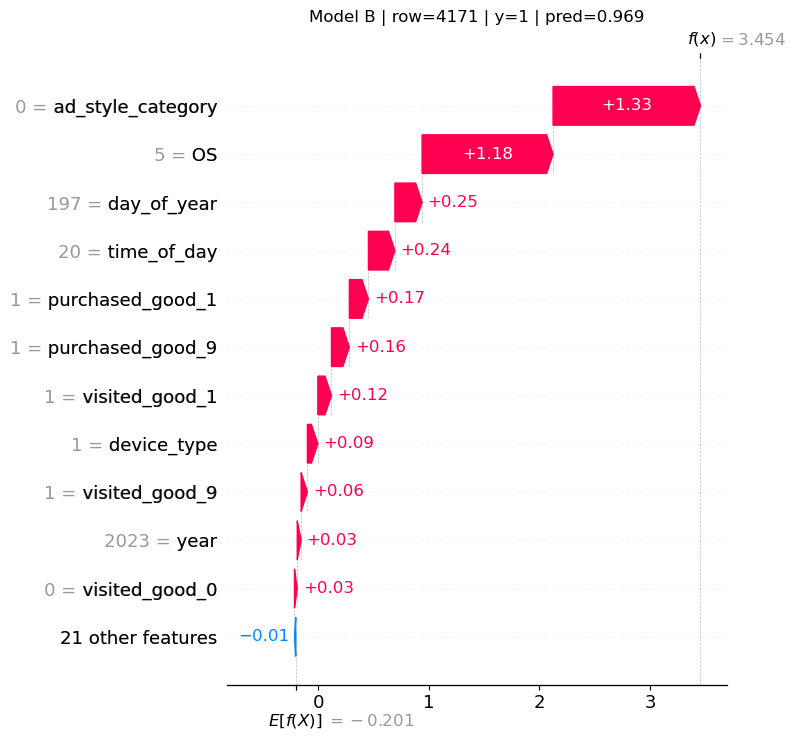

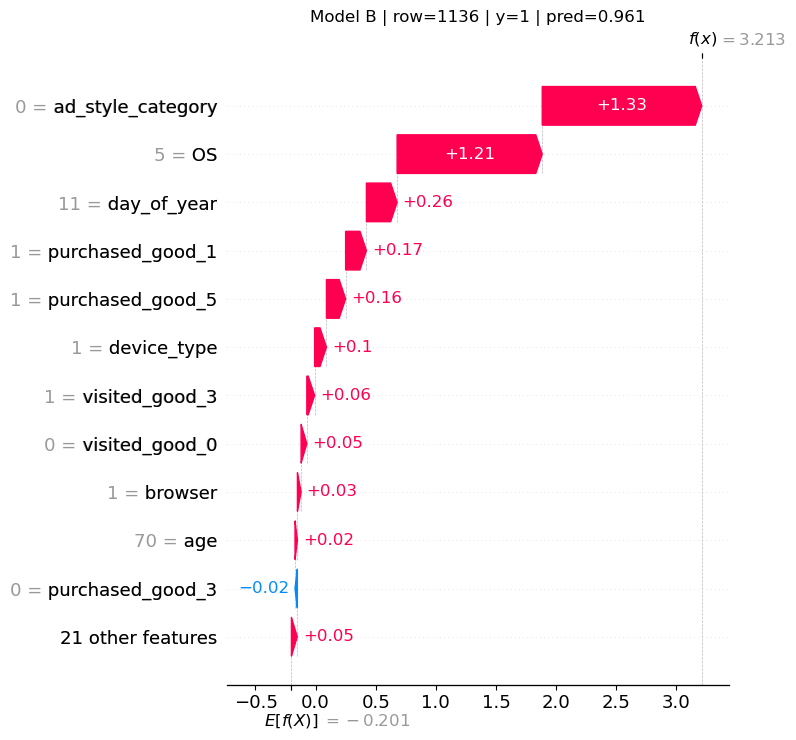

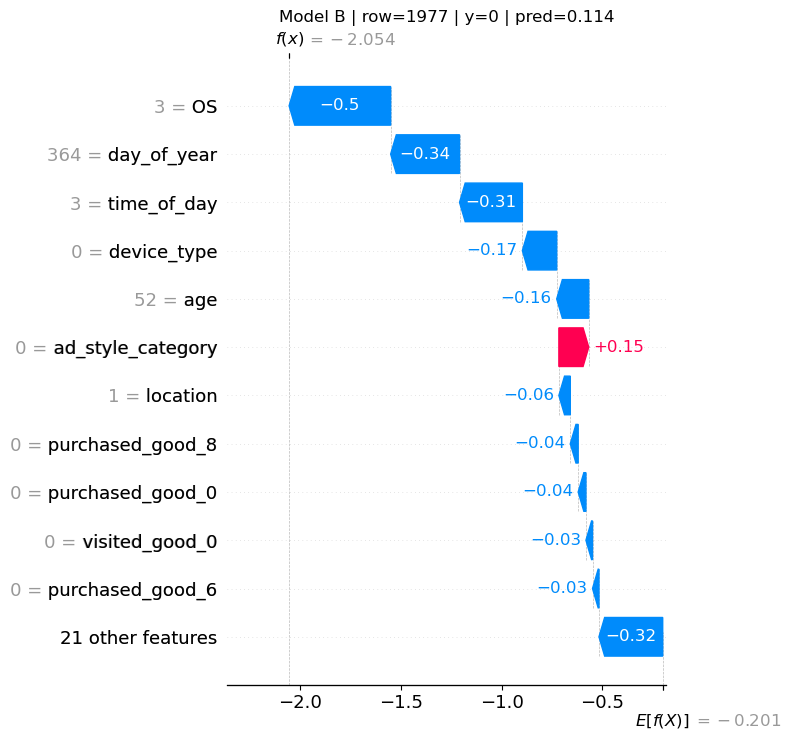

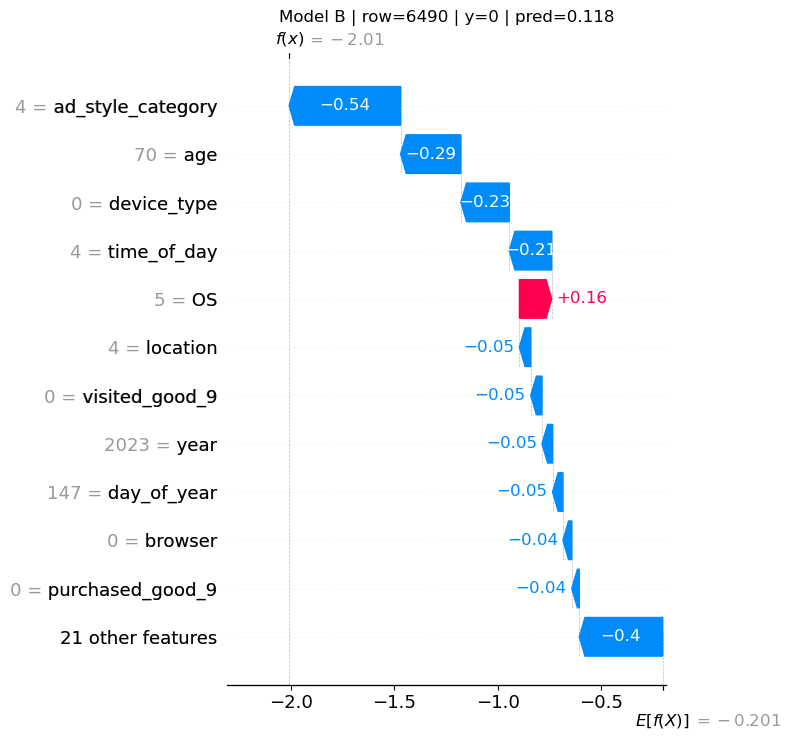

---- CONCLUSION ----
           ROCAUC     PRAUC   LogLoss  Accuracy        F1
Model A  0.791074  0.809641  0.498999   0.73568  0.627172
Model B  0.647760  0.624065  0.643527   0.61352  0.473346

Composite score A = 1.1017
Composite score B = 0.6283
VERDICT: Model A

Why:
- Model A has stronger discrimination (higher ROC-AUC / PR-AUC).
- Model A has better calibrated probabilities (lower LogLoss).
- Overall it is the more reliable classifier for ranking and probability-based decisions.


In [2]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss,
    accuracy_score, f1_score
)

import xgboost as xgb


# -----------------------------
# CONFIG (edit paths/cols here)
# -----------------------------
DATAPATH   = "click_prediction.csv"
MODELAPATH = "add_model_A.json"
MODELBPATH = "add_model_B.json"

LABEL_COL = "clicked_on_add"

FEATURE_COLS = [
    "id","year","day_of_year","time_of_day","device_type","location","age","browser","OS",
    "ad_style_category","part_of_add_evaluation_focus_group","provided_feedback_about_add",
    "visited_good_0","visited_good_1","visited_good_2","visited_good_3","visited_good_4",
    "visited_good_5","visited_good_6","visited_good_7","visited_good_8","visited_good_9",
    "purchased_good_0","purchased_good_1","purchased_good_2","purchased_good_3","purchased_good_4",
    "purchased_good_5","purchased_good_6","purchased_good_7","purchased_good_8","purchased_good_9"
]

RANDOM_STATE = 42
TEST_SIZE = 0.25

# SHAP settings
N_SHAP_SAMPLE = 2000   # speed: SHAP on subset of test
WATERFALL_MAX_DISPLAY = 12
N_LOCAL_PER_CLASS = 2


# -----------------------------
# Helpers
# -----------------------------
def load_booster(path: str) -> xgb.Booster:
    booster = xgb.Booster()
    booster.load_model(path)
    return booster

def safe_column_check(df: pd.DataFrame, required_cols: list[str]):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"These required columns are missing in the CSV: {missing}")

def predict_proba_booster(booster: xgb.Booster, Xdf: pd.DataFrame) -> np.ndarray:
    dmat = xgb.DMatrix(Xdf, feature_names=Xdf.columns.tolist())
    # For binary:logistic, this returns probability of class 1
    return booster.predict(dmat)

def evaluate_binary(y_true: np.ndarray, y_proba: np.ndarray, thr: float = 0.5) -> dict:
    y_pred = (y_proba >= thr).astype(int)
    return {
        "ROCAUC": roc_auc_score(y_true, y_proba),
        "PRAUC": average_precision_score(y_true, y_proba),
        "LogLoss": log_loss(y_true, y_proba),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

def mean_abs_shap(shap_values: np.ndarray, columns: list[str], top_k: int = 15) -> pd.Series:
    # shap_values shape: (n_samples, n_features)
    return pd.Series(np.abs(shap_values).mean(axis=0), index=columns).sort_values(ascending=False).head(top_k)

def pick_local_indices(y_true: np.ndarray, y_proba: np.ndarray, each: int = 2):
    """
    Pick:
      - 'each' positives with highest predicted probas
      - 'each' negatives with lowest predicted probas
    """
    y_true = np.asarray(y_true)
    idx = np.arange(len(y_true))

    pos = idx[y_true == 1]
    neg = idx[y_true == 0]

    if len(pos) > 0:
        pos_sorted = pos[np.argsort(-y_proba[pos])]
        pos_take = pos_sorted[:min(each, len(pos_sorted))].tolist()
    else:
        pos_take = []

    if len(neg) > 0:
        neg_sorted = neg[np.argsort(y_proba[neg])]
        neg_take = neg_sorted[:min(each, len(neg_sorted))].tolist()
    else:
        neg_take = []

    return pos_take + neg_take


# -----------------------------
# 1) Load data
# -----------------------------
df = pd.read_csv(DATAPATH)

safe_column_check(df, FEATURE_COLS + [LABEL_COL])

X = df[FEATURE_COLS].copy()
y = df[LABEL_COL].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Shapes:", X_train.shape, X_test.shape)


# -----------------------------
# 2) Load models
# -----------------------------
boosterA = load_booster(MODELAPATH)
boosterB = load_booster(MODELBPATH)


# -----------------------------
# 3) Predict + evaluate
# -----------------------------
probaA = predict_proba_booster(boosterA, X_test)
probaB = predict_proba_booster(boosterB, X_test)

resA = evaluate_binary(y_test.values, probaA)
resB = evaluate_binary(y_test.values, probaB)

metrics = pd.DataFrame([resA, resB], index=["Model A", "Model B"])
metrics


# -----------------------------
# 4) SHAP global explanations
# -----------------------------
# Sample for speed (like your Tryouts)
X_shap = X_test.sample(n=min(N_SHAP_SAMPLE, len(X_test)), random_state=RANDOM_STATE).copy()

explainerA = shap.TreeExplainer(boosterA)
explainerB = shap.TreeExplainer(boosterB)

svA = explainerA.shap_values(X_shap)
svB = explainerB.shap_values(X_shap)

# Beeswarm
shap.summary_plot(svA, X_shap, show=False)
plt.title("Model A - SHAP Summary (Beeswarm)")
plt.show()

shap.summary_plot(svB, X_shap, show=False)
plt.title("Model B - SHAP Summary (Beeswarm)")
plt.show()

# Bar (mean |SHAP|)
shap.summary_plot(svA, X_shap, plot_type="bar", show=False)
plt.title("Model A - SHAP Global Importance (mean |SHAP|)")
plt.show()

shap.summary_plot(svB, X_shap, plot_type="bar", show=False)
plt.title("Model B - SHAP Global Importance (mean |SHAP|)")
plt.show()

# Optional: side-by-side feature importance comparison (top-15)
impA = mean_abs_shap(np.asarray(svA), X_shap.columns.tolist(), top_k=15)
impB = mean_abs_shap(np.asarray(svB), X_shap.columns.tolist(), top_k=15)

compare_imp = pd.DataFrame({"Model A": impA, "Model B": impB}).fillna(0.0)
compare_imp.plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Top-15 features by mean |SHAP|: Model A vs Model B")
plt.xlabel("mean |SHAP|")
plt.show()

metrics


# -----------------------------
# 5) Optional: local waterfalls (top clicked vs not clicked)
# -----------------------------
def plot_local_waterfalls(model_name: str, explainer: shap.TreeExplainer, Xref: pd.DataFrame, yref: np.ndarray, probref: np.ndarray,
                          each: int = 2, max_display: int = 12):
    chosen = pick_local_indices(yref, probref, each=each)
    if not chosen:
        print(f"[{model_name}] No rows available for local waterfalls.")
        return

    X_local = Xref.iloc[chosen].copy()

    # TreeExplainer returns explanation compatible with waterfall via shap.Explanation
    exp_local = explainer(X_local)

    for j, rowid in enumerate(chosen):
        plt.figure(figsize=(9, 6))
        shap.plots.waterfall(exp_local[j], show=False, max_display=max_display)
        plt.title(f"{model_name} | row={rowid} | y={int(yref[rowid])} | pred={probref[rowid]:.3f}")
        plt.tight_layout()
        plt.show()

print("Local waterfalls - Model A")
plot_local_waterfalls("Model A", explainerA, X_test.reset_index(drop=True), y_test.reset_index(drop=True).values, probaA, each=N_LOCAL_PER_CLASS, max_display=WATERFALL_MAX_DISPLAY)

print("Local waterfalls - Model B")
plot_local_waterfalls("Model B", explainerB, X_test.reset_index(drop=True), y_test.reset_index(drop=True).values, probaB, each=N_LOCAL_PER_CLASS, max_display=WATERFALL_MAX_DISPLAY)


# -----------------------------
# 6) Conclusion / Verdict (Model better + why)
# -----------------------------
# A simple composite score you can explain in your report:
# Prefer higher ROCAUC and PRAUC, and lower LogLoss (probability quality)
scoreA = metrics.loc["Model A", "ROCAUC"] + metrics.loc["Model A", "PRAUC"] - metrics.loc["Model A", "LogLoss"]
scoreB = metrics.loc["Model B", "ROCAUC"] + metrics.loc["Model B", "PRAUC"] - metrics.loc["Model B", "LogLoss"]

better = "Model A" if scoreA > scoreB else "Model B"

print("---- CONCLUSION ----")
print(metrics)
print()
print(f"Composite score A = {scoreA:.4f}")
print(f"Composite score B = {scoreB:.4f}")
print(f"VERDICT: {better}")
print()
print("Why:")
if better == "Model A":
    print("- Model A has stronger discrimination (higher ROC-AUC / PR-AUC).")
    print("- Model A has better calibrated probabilities (lower LogLoss).")
    print("- Overall it is the more reliable classifier for ranking and probability-based decisions.")
else:
    print("- Model B has stronger discrimination (higher ROC-AUC / PR-AUC).")
    print("- Model B has better calibrated probabilities (lower LogLoss).")
    print("- Overall it is the more reliable classifier for ranking and probability-based decisions.")